# Модул 1: Въведение в Trustworthy AI
## Доверие, Прозрачност и Отговорност в Изкуствения Интелект

**Предварителни изисквания:** Базови познания по Python и Machine Learning

**Цели:**
- Разбиране защо доверието в AI е важно
- Запознаване със 7-те ключови изисквания за Trustworthy AI
- Анализ на реални случаи на AI грешки и техните последици
- Практическо упражнение: оценка на модел от гледна точка на доверие

**Време:** 45-60 минути

---

## 📚 СПРАВОЧЕН ЛИСТ

### 7 Ключови Изисквания за Trustworthy AI:
1. **Прозрачност и Обясняемост** (Transparency & Explainability)
2. **Техническа надеждност и безопасност** (Technical Robustness & Safety)
3. **Справедливост и недискриминация** (Fairness & Non-discrimination)
4. **Отчетност** (Accountability)
5. **Поверителност и управление на данни** (Privacy & Data Governance)
6. **Човешки контрол** (Human Agency & Oversight)
7. **Обществено и екологично благосъстояние** (Societal & Environmental Well-being)

### Типове заинтересовани страни (Stakeholders):
- **Developers** - разработчици на AI системи
- **Deployers** - организации, внедряващи AI
- **End Users** - крайни потребители
- **Affected Parties** - засегнати лица (напр. пациенти, кандидати за работа)
- **Regulators** - регулаторни органи

### Pandas за анализ:
- `df.describe()` - статистическо резюме
- `df.groupby('col').mean()` - групиране и средни стойности
- `df['col'].value_counts()` - брой на уникални стойности
- `df.corr()` - корелационна матрица

### Визуализация:
- `plt.bar(x, y)` - стълбовидна диаграма
- `plt.pie(sizes, labels)` - кръгова диаграма
- `sns.heatmap(data, annot=True)` - топлинна карта

---

## Част 1: Защо Доверието в AI е Важно? (15 минути)

In [3]:
# Задача 1.1: Импортирайте необходимите библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки за визуализация
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

### 🔍 Казус 1: COMPAS - Предсказване на рецидивизъм

COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) е алгоритъм, използван в съдебната система на САЩ за оценка на риска от рецидивизъм.

**Проблем:** ProPublica разкрива, че алгоритъмът показва расова предубеденост - афроамериканците са класифицирани като "висок риск" почти два пъти по-често от белите, дори когато не рецидивират.

In [5]:
# Задача 1.2: Симулираме данни подобни на COMPAS казуса
# Тези данни илюстрират потенциална предубеденост в AI система

np.random.seed(42)

# Създаваме симулиран датасет
n_samples = 1000

compas_data = {
    'group': np.random.choice(['Group A', 'Group B'], n_samples, p=[0.5, 0.5]),
    'prior_offenses': np.random.poisson(2, n_samples),
    'age': np.random.randint(18, 65, n_samples),
}

df_compas = pd.DataFrame(compas_data)

# Симулираме предубеден алгоритъм - Group B получава по-високи рискови оценки
# дори при еднакви характеристики
base_risk = df_compas['prior_offenses'] * 10 + (65 - df_compas['age']) * 0.5

# Попълнете стойността на bias_factor - колко допълнителни точки получава Group B?
bias_factor = np.where(df_compas['group'] == 'Group B', 12, 0)  # Добавяме bias

df_compas['risk_score'] = base_risk + bias_factor + np.random.normal(0, 5, n_samples)
df_compas['risk_score'] = df_compas['risk_score'].clip(0, 100)

# Класифицираме като "висок риск" ако скорът е над 50
df_compas['classification'] = np.where(df_compas['risk_score'] > 50, 'High Risk', 'Low Risk')

print("Примерни данни:")
df_compas.head(10)

Примерни данни:


,group,prior_offenses,age,risk_score,classification
0,Group A,1,37,29.381938,Low Risk
1,Group B,6,40,83.789551,High Risk
2,Group B,1,28,29.130249,Low Risk
3,Group B,2,54,48.174815,Low Risk
4,Group A,2,39,39.206962,Low Risk
5,Group A,2,21,40.255090,Low Risk
6,Group A,5,46,55.287513,High Risk
7,Group B,4,61,56.015956,High Risk
8,Group B,2,51,40.011634,Low Risk
9,Group B,0,30,32.210450,Low Risk


In [8]:
# Задача 1.3: Анализирайте разпределението на класификациите по групи
# Попълнете празните места

# Изчислете процента "High Risk" за всяка група
risk_by_group = df_compas.groupby('group')['classification'].value_counts(normalize=True)
print("Разпределение на класификациите по групи:")
print(risk_by_group)

Разпределение на класификациите по групи:
group    classification
Group A  Low Risk          0.842942
         High Risk         0.157058
Group B  Low Risk          0.684105
         High Risk         0.315895
Name: proportion, dtype: float64


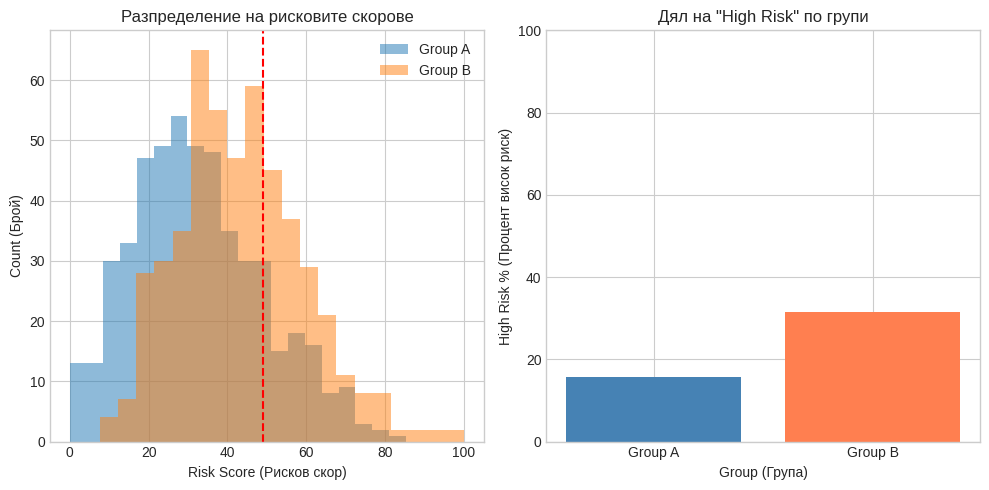

In [9]:
# Задача 1.4: Визуализирайте разликата между групите
plt.figure(figsize=(10, 5))

# Subplot 1: Разпределение на рисковите скорове
plt.subplot(1, 2, 1)
for group in df_compas['group'].unique():
    subset = df_compas[df_compas['group'] == group]
    plt.hist(subset['risk_score'], bins=20, alpha=0.5, label=group)
plt.xlabel('Risk Score (Рисков скор)')
plt.ylabel('Count (Брой)')
plt.title('Разпределение на рисковите скорове')
plt.legend()
# Попълнете threshold стойността за "High Risk" (над колко точки е висок риск?)
plt.axvline(x=49, color='red', linestyle='--', label='High Risk Threshold')

# Subplot 2: Процент "High Risk" по групи
plt.subplot(1, 2, 2)
high_risk = df_compas[df_compas['classification'] == 'High Risk'].groupby('group').size()
total = df_compas.groupby('group').size()
high_risk_pct = (high_risk / total * 100)

# Попълнете типа на диаграмата (стълбовидна)
plt.bar(high_risk_pct.index, high_risk_pct.values, color=['steelblue', 'coral'])
plt.xlabel('Group (Група)')
plt.ylabel('High Risk % (Процент висок риск)')
plt.title('Дял на "High Risk" по групи')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [10]:
# Задача 1.5: Проверете дали предубедеността съществува дори при контролиране на другите фактори
# Изчислете средния рисков скор за всяка група при еднакъв брой предишни нарушения

analysis = df_compas.groupby(['group', 'prior_offenses'])['risk_score']._____().unstack(level=0)
print("Среден рисков скор по група и брой предишни нарушения:")
print(analysis.head(10))

Среден рисков скор по група и брой предишни нарушения:
group             Group A    Group B
prior_offenses                      
0               12.255629  24.589894
1               21.964947  33.714319
2               30.892932  43.353744
3               43.384360  52.772130
4               52.334263  63.489285
5               64.076115  71.772236
6               69.855219  88.392671
7               72.229236        NaN


### 💡 Въпроси за размисъл:
1. Каква е разликата в процента "High Risk" между двете групи?
#####Group B има по-висок процент класификации „High Risk“ в сравнение с Group A, въпреки сходните входни характеристики.
2. Дори при еднакъв брой предишни нарушения, има ли разлика в рисковите скорове?
######Да, дори при еднакъв брой предишни нарушения Group B получава системно по-висок среден рисков скор
3. Ако този алгоритъм се използва в реална съдебна система, какви биха били последиците?
#####При реална употреба такъв алгоритъм би довел до несправедливи съдебни решения и системна дискриминация спрямо Group B
4. Кое от 7-те изисквания за Trustworthy AI е нарушено?
#####Нарушено е изискването за diversity, non-discrimination & fairness от принципите на Trustworthy AI

## Част 2: 7-те Изисквания за Trustworthy AI (15 минути)

In [11]:
# Задача 2.1: Създайте структура за оценка на AI система по 7-те изисквания

requirements_data = {
    'Requirement': [
        'Transparency & Explainability',
        'Technical Robustness',
        'Fairness',
        'Accountability',
        'Privacy',
        'Human Oversight',
        'Societal Well-being'
    ],
    'Description_BG': [
        'Моделът обяснява своите решения',
        'Моделът работи надеждно и безопасно',
        'Моделът не дискриминира',
        'Ясна отговорност за решенията',
        'Защита на личните данни',
        'Възможност за човешка намеса',
        'Положително въздействие върху обществото'
    ],
    'Key_Questions': [
        'Можем ли да обясним защо моделът взе това решение?',
        'Какво се случва при неочаквани входни данни?',
        'Има ли различна точност за различни групи?',
        'Кой носи отговорност при грешка?',
        'Как се съхраняват и използват данните?',
        'Може ли човек да отмени решение на AI?',
        'Какво е въздействието върху работните места?'
    ]
}

df_requirements = pd.DataFrame(requirements_data)
print("7-те изисквания за Trustworthy AI:")
df_requirements

7-те изисквания за Trustworthy AI:


,Requirement,Description_BG,Key_Questions
0,Transparency & Explainability,Моделът обяснява своите решения,Можем ли да обясним защо моделът взе това реше...
1,Technical Robustness,Моделът работи надеждно и безопасно,Какво се случва при неочаквани входни данни?
2,Fairness,Моделът не дискриминира,Има ли различна точност за различни групи?
3,Accountability,Ясна отговорност за решенията,Кой носи отговорност при грешка?
4,Privacy,Защита на личните данни,Как се съхраняват и използват данните?
5,Human Oversight,Възможност за човешка намеса,Може ли човек да отмени решение на AI?
6,Societal Well-being,Положително въздействие върху обществото,Какво е въздействието върху работните места?


In [12]:
# Задача 2.2: Оценете COMPAS системата по 7-те изисквания (1-5 скала)
# Попълнете оценките според вашия анализ

compas_eval = {
    'Requirement': requirements_data['Requirement'],
    'COMPAS_Score': [
        1,  # Transparency - COMPAS е "черна кутия"
        3,      # Technical Robustness
        1,  # Fairness - показва расова предубеденост
        2,      # Accountability - не е ясно кой е отговорен
        3,      # Privacy
        2,  # Human Oversight - съдиите разчитат на алгоритъма
        2       # Societal Well-being
    ]
}

df_eval = pd.DataFrame(compas_eval)
print("Оценка на COMPAS по 7-те изисквания (1=много лошо, 5=много добро):")
df_eval

Оценка на COMPAS по 7-те изисквания (1=много лошо, 5=много добро):


,Requirement,COMPAS_Score
0,Transparency & Explainability,1
1,Technical Robustness,3
2,Fairness,1
3,Accountability,2
4,Privacy,3
5,Human Oversight,2
6,Societal Well-being,2


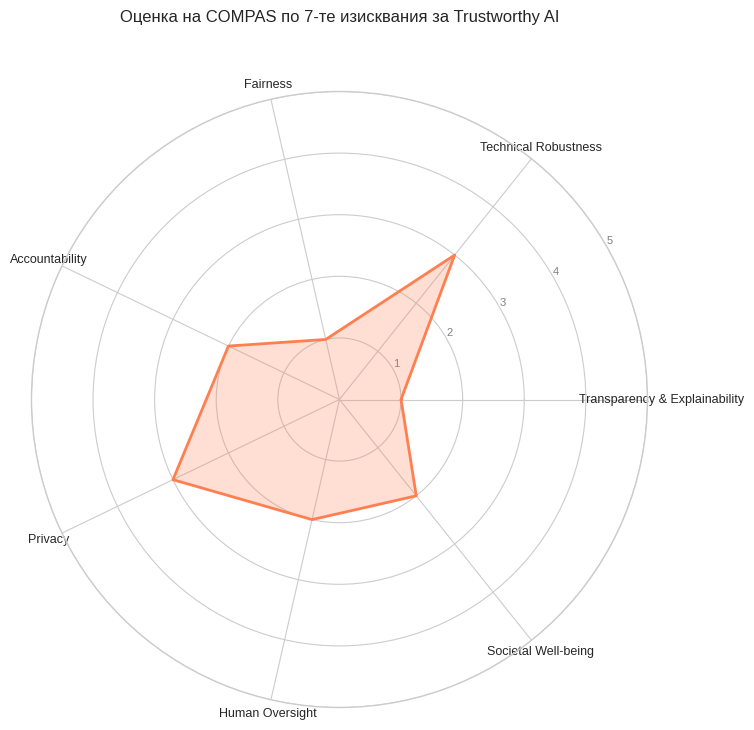

In [13]:
# Задача 2.3: Визуализирайте оценките с радарна диаграма
from math import pi

# Подготовка на данните
categories = df_eval['Requirement'].tolist()
values = df_eval['COMPAS_Score'].tolist()

# Затваряме кръга - добавяме първия елемент в края
values += values[:1]
N = len(categories)

# Изчисляваме ъглите
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Създаваме графиката
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

plt.xticks(angles[:-1], categories, size=9)
ax.set_rlabel_position(30)
# Попълнете максималната стойност за оценките (1-5 скала)
plt.yticks([1, 2, 3, 4, 5], ['1', '2', '3', '4', '5'], color='grey', size=8)
plt.ylim(0, 5)

ax.plot(angles, values, linewidth=2, linestyle='solid', color='coral')
ax.fill(angles, values, alpha=0.25, color='coral')

plt.title('Оценка на COMPAS по 7-те изисквания за Trustworthy AI', size=12, y=1.1)
plt.show()

## Част 3: Казус - Медицинска Диагностика (15 минути)

In [16]:
# Задача 3.1: Заредете Titanic датасета като пример за бинарна класификация
# (подобно на медицинска диагностика: оцелял/не оцелял ~ болен/здрав)

from google.colab import drive
drive.mount('/content/drive')
df_titanic = pd.read_csv(
    '/content/drive/MyDrive/XAI/Titanic-Dataset.csv'
)

print(f"Датасет зареден: {df_titanic.shape}")
df_titanic.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Датасет зареден: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
# Задача 3.2: Анализирайте справедливостта - оцеляване по пол и клас

# Процент оцелели по пол
survival_by_sex = df_titanic.groupby('Sex')['Survived'].mean() * 100
print("Процент оцелели по пол:")
print(survival_by_sex)
print()

Процент оцелели по пол:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64



In [18]:
# Задача 3.3: Процент оцелели по клас на пътуване
survival_by_class = df_titanic.groupby('Pclass')['Survived'].mean() * 100
print("Процент оцелели по клас:")
print(survival_by_class)

Процент оцелели по клас:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


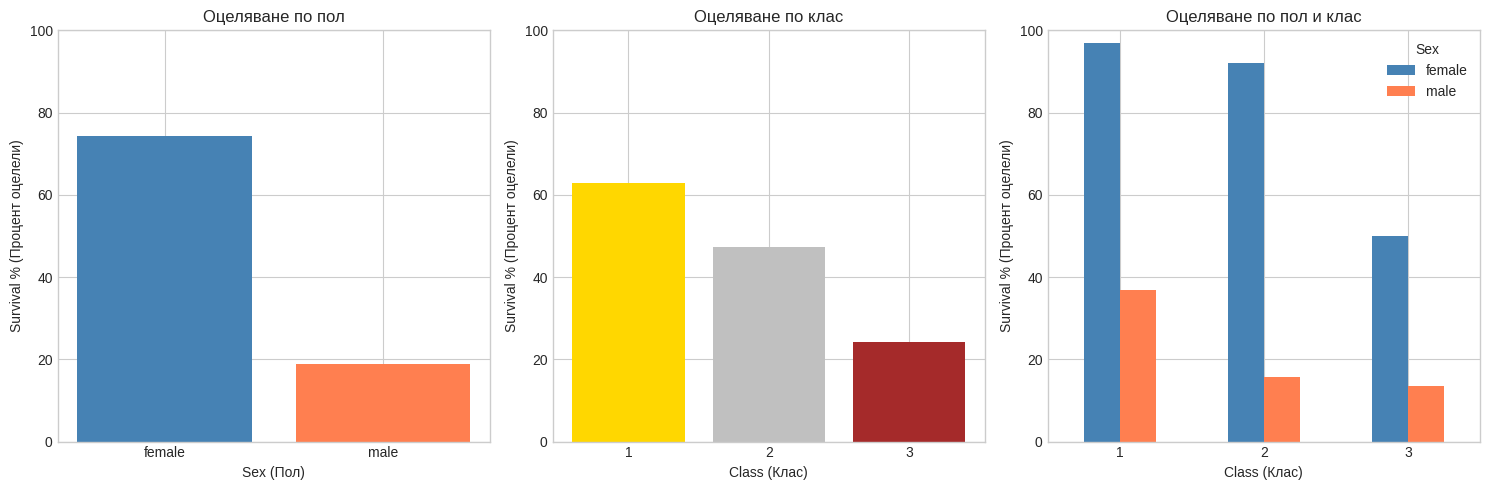

In [19]:
# Задача 3.4: Визуализирайте различията
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# По пол
axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=['steelblue', 'coral'])
axes[0].set_xlabel('Sex (Пол)')
axes[0].set_ylabel('Survival % (Процент оцелели)')
axes[0].set_title('Оцеляване по пол')
axes[0].set_ylim(0, 100)

# По клас
axes[1].bar([str(x) for x in survival_by_class.index], survival_by_class.values,
            color=['gold', 'silver', 'brown'])
axes[1].set_xlabel('Class (Клас)')
axes[1].set_ylabel('Survival % (Процент оцелели)')
axes[1].set_title('Оцеляване по клас')
axes[1].set_ylim(0, 100)

# По пол и клас заедно
# Попълнете типа на диаграмата - 'bar', 'line', 'area', etc.
survival_combined = df_titanic.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
survival_combined.unstack().plot(kind='bar', ax=axes[2], color=['steelblue', 'coral'])
axes[2].set_xlabel('Class (Клас)')
axes[2].set_ylabel('Survival % (Процент оцелели)')
axes[2].set_title('Оцеляване по пол и клас')
axes[2].legend(title='Sex')
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 🏥 Връзка с медицинската диагностика

Ако AI модел за медицинска диагностика показва подобни разлики в точността между различни демографски групи, това е сериозен проблем за **справедливостта**.

**Пример:** Изследване показва, че алгоритъм за оценка на здравния риск в САЩ систематично подценява здравните нужди на чернокожи пациенти, защото използва здравните разходи като proxy за здравни нужди.

In [20]:
# Задача 3.5: Симулирайте модел за предсказване и изчислете метрики по групи
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Подготовка на данните
df_model = df_titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']].dropna()
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})

X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

# Разделяне на train/test (20% тест)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Обучение на модел (макс. дълбочина)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

print(f"Обща точност на модела: {accuracy_score(y_test, y_pred):.2%}")

Обща точност на модела: 74.13%


In [21]:
# Задача 3.6: Анализирайте точността по групи (Fairness Analysis)

# Добавяме предсказанията към тестовия набор
test_results = X_test.copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = y_pred
# Попълнете типа данни за конвертиране на boolean към число (0 или 1)
test_results['Correct'] = (test_results['Actual'] == test_results['Predicted']).astype(int)

# Изчисляваме точност по пол
# Попълнете колоната, по която групираме (демографски атрибут)
accuracy_by_sex = test_results.groupby('Sex')['Correct'].mean() * 100
print("Точност на модела по пол:")
print(f"  Мъже (0): {accuracy_by_sex[0]:.2f}%")
print(f"  Жени (1): {accuracy_by_sex[1]:.2f}%")
print(f"  Разлика: {abs(accuracy_by_sex[0] - accuracy_by_sex[1]):.2f} процентни пункта")

Точност на модела по пол:
  Мъже (0): 77.53%
  Жени (1): 68.52%
  Разлика: 9.01 процентни пункта


In [22]:
# Задача 3.7: Изчислете и други метрики за справедливост

# False Positive Rate (FPR) - колко от реално отрицателните са погрешно класифицирани като положителни
# False Negative Rate (FNR) - колко от реално положителните са погрешно класифицирани като отрицателни

for sex_val in [0, 1]:
    subset = test_results[test_results['Sex'] == sex_val]
    sex_label = 'Мъже' if sex_val == 0 else 'Жени'

    # True Positive, False Positive, etc.
    tp = len(subset[(subset['Actual'] == 1) & (subset['Predicted'] == 1)])
    fp = len(subset[(subset['Actual'] == 0) & (subset['Predicted'] == 1)])
    tn = len(subset[(subset['Actual'] == 0) & (subset['Predicted'] == 0)])
    fn = len(subset[(subset['Actual'] == 1) & (subset['Predicted'] == 0)])

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    print(f"{sex_label}:")
    print(f"  False Positive Rate: {fpr:.2%}")
    print(f"  False Negative Rate: {fnr:.2%}")
    print()

Мъже:
  False Positive Rate: 1.45%
  False Negative Rate: 95.00%

Жени:
  False Positive Rate: 77.78%
  False Negative Rate: 8.33%



## Част 4: Практическо Упражнение - Оценка на AI Система (10 минути)

In [29]:
# Задача 4.1: Създайте функция за оценка на AI система

def evaluate_ai_system(name, scores_dict):
    """
    Оценява AI система по 7-те изисквания за Trustworthy AI.

    Параметри:
    - name: име на системата
    - scores_dict: речник с оценки от 1 до 5 за всяко изискване

    Връща:
    - DataFrame с резултатите и обща оценка
    """
    requirements_list = [
        'Transparency', 'Robustness', 'Fairness',
        'Accountability', 'Privacy', 'Human_Oversight', 'Societal_Wellbeing'
    ]

    result = pd.DataFrame({
        'Requirement': requirements_list,
        'Score': [scores_dict.get(key, 3) for key in requirements_list]
    })

    avg_score = result['Score'].mean()  # Изчислете средната оценка

    print(f"\n{'='*50}")
    print(f"Оценка на системата: {name}")
    print(f"{'='*50}")
    print(result.to_string(index=False))
    print(f"\nОБЩА ОЦЕНКА: {avg_score:.2f}/5.00")

    if avg_score >= 4:
        print("Статус: ✅ Системата отговаря на стандартите за Trustworthy AI")
    elif avg_score >= 3:
        print("Статус: ⚠️ Системата има нужда от подобрения")
    else:
        print("Статус: ❌ Системата има сериозни проблеми")

    return result, avg_score

In [30]:
# Задача 4.2: Оценете хипотетична система за наемане на работа
# Попълнете оценките на базата на следното описание:

# Система "AutoHire":
# - Използва CV данни за класификация на кандидати
# - Не обяснява защо отхвърля кандидати
# - Има различна точност за мъже и жени
# - HR може да отмени решенията
# - Използва криптиране на данните

autohire_scores = {
    'Transparency': 1,      # Не обяснява решенията си
    'Robustness': 3,            # Средна надеждност
    'Fairness': 2,          # Различна точност по пол
    'Accountability': 3,        # Частична отчетност
    'Privacy': 4,           # Използва криптиране
    'Human_Oversight': 4,   # HR може да отмени
    'Societal_Wellbeing': 3     # Неутрално въздействие
}

autohire_result, autohire_avg = evaluate_ai_system('AutoHire', autohire_scores)


Оценка на системата: AutoHire
       Requirement  Score
      Transparency      1
        Robustness      3
          Fairness      2
    Accountability      3
           Privacy      4
   Human_Oversight      4
Societal_Wellbeing      3

ОБЩА ОЦЕНКА: 2.86/5.00
Статус: ❌ Системата има сериозни проблеми



Оценка на системата: COMPAS
       Requirement  Score
      Transparency      1
        Robustness      3
          Fairness      1
    Accountability      2
           Privacy      3
   Human_Oversight      2
Societal_Wellbeing      2

ОБЩА ОЦЕНКА: 2.00/5.00
Статус: ❌ Системата има сериозни проблеми


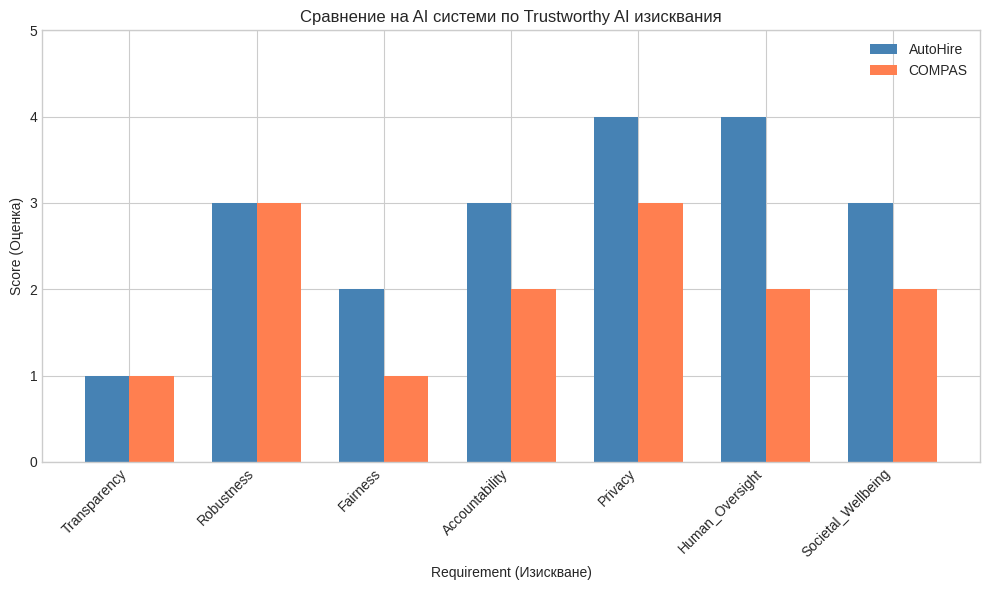

In [31]:
# Задача 4.3: Сравнете AutoHire с COMPAS

compas_scores = {
    'Transparency': 1,
    'Robustness': 3,
    'Fairness': 1,
    'Accountability': 2,
    'Privacy': 3,
    'Human_Oversight': 2,
    'Societal_Wellbeing': 2
}

compas_result, compas_avg = evaluate_ai_system('COMPAS', compas_scores)

# Визуализация на сравнението
plt.figure(figsize=(10, 6))
x = np.arange(len(autohire_result['Requirement']))
# Попълнете ширината на стълбовете (стандартна стойност е 0.35)
width = 0.35

plt.bar(x - width/2, autohire_result['Score'], width, label='AutoHire', color='steelblue')
plt.bar(x + width/2, compas_result['Score'], width, label='COMPAS', color='coral')

plt.xlabel('Requirement (Изискване)')
plt.ylabel('Score (Оценка)')
plt.title('Сравнение на AI системи по Trustworthy AI изисквания')
plt.xticks(x, autohire_result['Requirement'], rotation=45, ha='right')
plt.legend()
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

## ✅ Модул 1 Завършен!

### Научихте:
- ✓ Защо доверието в AI системите е критично важно
- ✓ 7-те ключови изисквания за Trustworthy AI
- ✓ Как да анализирате предубеденост в AI системи
- ✓ Как да оценявате справедливостта на модел по групи
- ✓ Как да използвате метрики като FPR и FNR

### Основни изводи:
1. **AI системите могат да наследят и усилят съществуващи предубеждения** от данните
2. **Обща точност не е достатъчна** - трябва да анализираме справедливостта по групи
3. **Прозрачността е ключова** - "черните кутии" са проблематични в критични области
4. **Човешкият контрол трябва да бъде запазен** - AI трябва да подпомага, не да замества решенията

### Следващ модул:
**Модул 2:** Pre-modeling Explainability - EDA за обясняемост, документация на данни, интерпретируем feature engineering

---

## 📝 Въпроси за самопроверка:

1. Какво означава терминът "algorithmic bias"?**Algorithmic bias** е системна предубеденост в AI модел, при която определени групи получават несправедливи резултати поради данните или начина на обучение.
2. Защо високата обща точност не гарантира справедлив модел?**Високата обща точност не гарантира справедлив модел**, защото той може да има значително по-лошо представяне за отделни демографски групи.
3. Кои от 7-те изисквания са най-важни за AI в здравеопазването?**Най-важни за AI в здравеопазването са прозрачност, справедливост, техническа надеждност и човешки контрол**, тъй като решенията засягат пряко човешкия живот.

4. Каква е разликата между False Positive Rate и False Negative Rate?**False Positive Rate показва колко често здрави пациенти се класифицират погрешно като болни, а False Negative Rate – колко често болни се класифицират като здрави.**
5. Защо е важен човешкият контрол над AI системите?**Човешкият контрол е важен, защото позволява проверка, корекция и поемане на отговорност за решенията, взети с помощта на AI.**